# 4 — Cães e gatos: uma CNN pequena com imagens RGB

**Objetivo.** Treinar do zero uma CNN binária em fotografias reais, entender RGB e redimensionamento, e separar corretamente treino, validação e teste.

Usaremos o conjunto público [Kaggle Cats and Dogs, distribuído pela Microsoft](https://www.microsoft.com/en-us/download/details.aspx?id=54765). Selecionaremos os mesmos intervalos do recorte didático usado no tutorial oficial do TensorFlow [Transfer learning and fine-tuning](https://www.tensorflow.org/tutorials/images/transfer_learning): índices 0–999 para desenvolvimento e 2000–2499 para teste final. O arquivo completo tem cerca de 825 MB e o cache fica em ~/.keras/datasets, fora deste repositório.

> Os índices 2000–2499 permanecem como **teste final**. A validação usada durante o treino sai apenas dos índices 0–999; assim nenhuma imagem do teste influencia o treinamento.

## 1. Preparação e download

Fotografias têm tamanhos diferentes. Vamos convertê-las para 128×128 pixels com três canais: vermelho, verde e azul. Redimensionar perde detalhes, mas torna os lotes retangulares e reduz o custo do exemplo.

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["OMP_NUM_THREADS"] = "2"

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.threading.set_intra_op_parallelism_threads(2)
tf.config.threading.set_inter_op_parallelism_threads(2)

plt.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.2,
})

print("TensorFlow", tf.__version__)

I0000 00:00:1789564569.902478 1667404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789564569.902731 1667404 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow 2.21.0


I0000 00:00:1789564570.554829 1667404 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789564570.554993 1667404 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
URL_DADOS = (
    "https://download.microsoft.com/download/3/E/1/"
    "3E1C3F21-ECDB-4869-8368-6DEBA77B919F/kagglecatsanddogs_5340.zip"
)
caminho = Path(tf.keras.utils.get_file(
    "kagglecatsanddogs_5340.zip",
    origin=URL_DADOS,
    extract=True,
))
pasta_extraida = caminho.parent if caminho.is_file() else caminho
base = pasta_extraida / "PetImages"
assert (base / "Cat").is_dir() and (base / "Dog").is_dir()
print("dados em cache:", base)

dados em cache: /home/gustavo/.keras/datasets/kagglecatsanddogs_5340_extracted/PetImages


## 2. Carregar e separar as imagens

O arquivo completo contém algumas imagens danificadas. Os dois laços abaixo abrem somente os 3.000 arquivos usados, convertem cada imagem para RGB e redimensionam. Arquivos inválidos são ignorados com uma mensagem curta.

In [3]:
TAMANHO = (128, 128)
imagens_pool, rotulos_pool = [], []

for pasta, rotulo in [("Cat", 0), ("Dog", 1)]:
    for indice in range(1000):
        caminho = base / pasta / f"{indice}.jpg"
        try:
            with Image.open(caminho) as imagem:
                imagem_rgb = imagem.convert("RGB").resize(
                    TAMANHO, Image.Resampling.BILINEAR
                )
            imagens_pool.append(np.asarray(imagem_rgb, dtype="uint8"))
            rotulos_pool.append(rotulo)
        except (OSError, ValueError):
            print("ignorada imagem inválida:", caminho.name)

ignorada imagem inválida: 666.jpg


In [4]:
imagens_teste, rotulos_teste = [], []

for pasta, rotulo in [("Cat", 0), ("Dog", 1)]:
    for indice in range(2000, 2500):
        caminho = base / pasta / f"{indice}.jpg"
        try:
            with Image.open(caminho) as imagem:
                imagem_rgb = imagem.convert("RGB").resize(
                    TAMANHO, Image.Resampling.BILINEAR
                )
            imagens_teste.append(np.asarray(imagem_rgb, dtype="uint8"))
            rotulos_teste.append(rotulo)
        except (OSError, ValueError):
            print("ignorada imagem inválida:", caminho.name)

x_pool = np.stack(imagens_pool)
y_pool = np.array(rotulos_pool, dtype="float32")
x_teste = np.stack(imagens_teste)
y_teste = np.array(rotulos_teste, dtype="float32")

n_por_classe = min(np.sum(y_pool == 0), np.sum(y_pool == 1))
indices_equilibrados = np.concatenate([
    np.flatnonzero(y_pool == 0)[:n_por_classe],
    np.flatnonzero(y_pool == 1)[:n_por_classe],
])
x_pool = x_pool[indices_equilibrados]
y_pool = y_pool[indices_equilibrados]
print("pool de desenvolvimento:", x_pool.shape)
print("teste final:", x_teste.shape)

pool de desenvolvimento: (1998, 128, 128, 3)
teste final: (1000, 128, 128, 3)


Dentro do pool de desenvolvimento, embaralhamos cada classe com a mesma semente e usamos 80% no treino e 20% na validação. Os índices do teste vieram de outro intervalo e nunca entram nessa divisão.

In [5]:
rng = np.random.default_rng(42)
indices_treino, indices_validacao = [], []

for classe in [0, 1]:
    indices_classe = np.flatnonzero(y_pool == classe)
    rng.shuffle(indices_classe)
    corte = int(0.8 * len(indices_classe))
    indices_treino.extend(indices_classe[:corte])
    indices_validacao.extend(indices_classe[corte:])

indices_treino = rng.permutation(indices_treino)
indices_validacao = rng.permutation(indices_validacao)
x_treino, y_treino = x_pool[indices_treino], y_pool[indices_treino]
x_validacao, y_validacao = x_pool[indices_validacao], y_pool[indices_validacao]

assert set(indices_treino).isdisjoint(indices_validacao)
assert set(range(1000)).isdisjoint(range(2000, 2500))
print(f"treino: {len(x_treino)} · validação: {len(x_validacao)} · teste: {len(x_teste)}")
print("rótulos: 0 = gato; 1 = cachorro")

treino: 1598 · validação: 400 · teste: 1000
rótulos: 0 = gato; 1 = cachorro


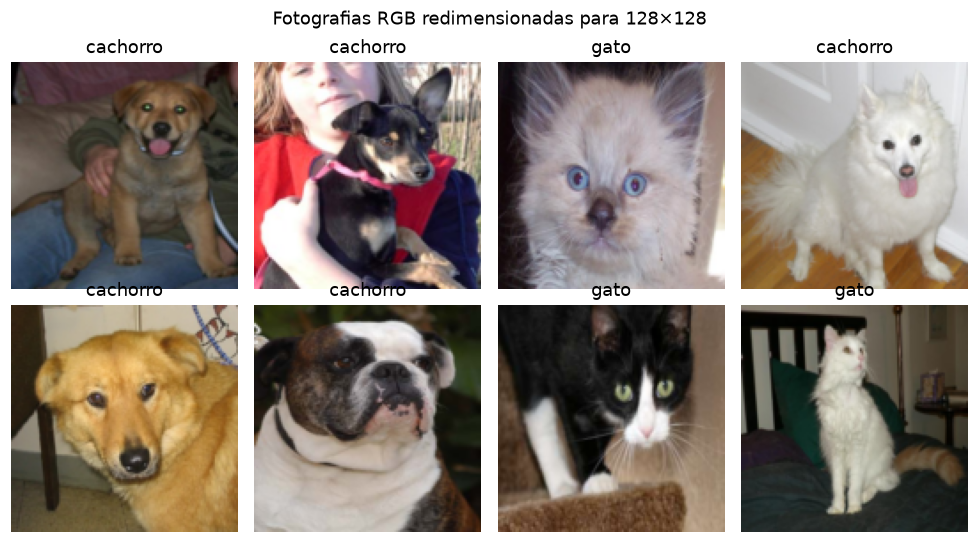

In [6]:
fig, eixos = plt.subplots(2, 4, figsize=(9, 5))
for eixo, imagem, rotulo in zip(eixos.flat, x_treino[:8], y_treino[:8]):
    eixo.imshow(imagem)
    eixo.set_title("cachorro" if rotulo == 1 else "gato")
    eixo.axis("off")
fig.suptitle("Fotografias RGB redimensionadas para 128×128")
plt.tight_layout()

## 3. Classificação binária

A primeira camada divide valores de pixel por 255. Depois, três blocos de convolução e pooling extraem padrões locais. Há somente um neurônio de saída:

- sigmoid produz um número entre 0 e 1, interpretado aqui como probabilidade de “cachorro”;
- abaixo de 0,5 prevemos “gato”; a partir de 0,5, “cachorro”;
- binary crossentropy penaliza probabilidades distantes do rótulo 0 ou 1.

O modelo aprende do zero por 4 épocas. Não há transferência de aprendizado, aumento de dados nem checkpoints.

In [7]:
modelo = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.Rescaling(1.0 / 255),
    tf.keras.layers.Conv2D(16, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(64, 3, activation="relu"),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
], name="cnn_caes_gatos")
modelo.summary()

E0000 00:00:1789564580.011864 1667404 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Model: "cnn_caes_gatos"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       401,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 425,057 (1.62 MB)

 Trainable params: 425,057 (1.62 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [9]:
historia = modelo.fit(
    x_treino,
    y_treino,
    validation_data=(x_validacao, y_validacao),
    epochs=4,
    batch_size=32,
    verbose=2,
)

Epoch 1/4


50/50 - 3s - 65ms/step - accuracy: 0.5056 - loss: 0.6951 - val_accuracy: 0.5000 - val_loss: 0.6907


Epoch 2/4


50/50 - 3s - 52ms/step - accuracy: 0.5488 - loss: 0.6856 - val_accuracy: 0.5925 - val_loss: 0.6740


Epoch 3/4


50/50 - 3s - 54ms/step - accuracy: 0.5970 - loss: 0.6617 - val_accuracy: 0.5925 - val_loss: 0.6716


Epoch 4/4


50/50 - 3s - 54ms/step - accuracy: 0.6333 - loss: 0.6365 - val_accuracy: 0.6225 - val_loss: 0.6577


## 4. Curvas e teste preservado

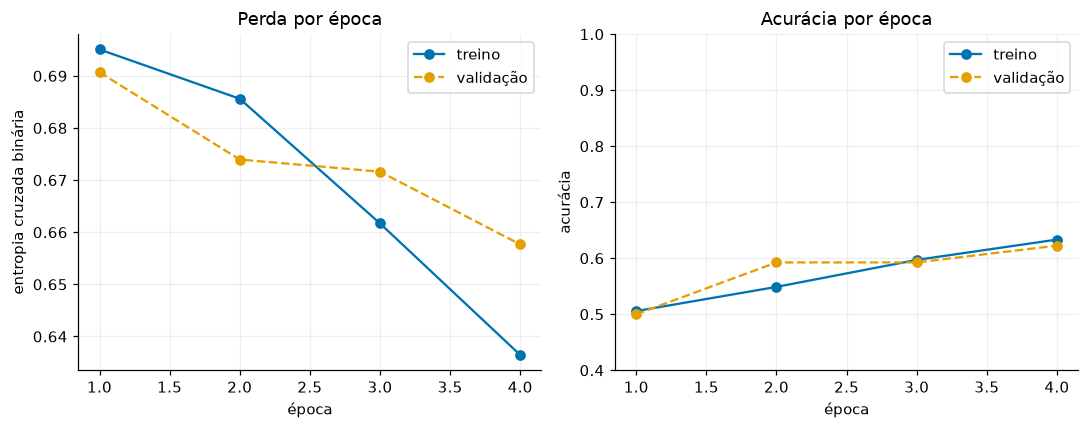

In [10]:
epocas = range(1, 5)
fig, eixos = plt.subplots(1, 2, figsize=(10, 4))
eixos[0].plot(epocas, historia.history["loss"], "o-", color="#0072B2", label="treino")
eixos[0].plot(epocas, historia.history["val_loss"], "o--", color="#E69F00", label="validação")
eixos[1].plot(epocas, historia.history["accuracy"], "o-", color="#0072B2", label="treino")
eixos[1].plot(epocas, historia.history["val_accuracy"], "o--", color="#E69F00", label="validação")
eixos[0].set(title="Perda por época", xlabel="época", ylabel="entropia cruzada binária")
eixos[1].set(title="Acurácia por época", xlabel="época", ylabel="acurácia", ylim=(0.4, 1.0))
for eixo in eixos:
    eixo.legend()
plt.tight_layout()

In [11]:
perda_teste, acc_teste = modelo.evaluate(x_teste, y_teste, verbose=0)
acc_treino_final = historia.history["accuracy"][-1]
acc_val_final = historia.history["val_accuracy"][-1]
print(f"Teste final preservado — perda: {perda_teste:.4f}; acurácia: {acc_teste:.4f}")
print(f"Última época — treino: {acc_treino_final:.4f}; validação: {acc_val_final:.4f}")
print(f"Lacuna treino − validação: {acc_treino_final - acc_val_final:+.4f}")

Teste final preservado — perda: 0.6306; acurácia: 0.6500
Última época — treino: 0.6333; validação: 0.6225
Lacuna treino − validação: +0.0108


Uma acurácia de treino maior que a de validação é um sinal compatível com memorização, mas a magnitude observada depende da amostra e da época. Quatro épocas e poucos milhares de imagens são deliberadamente modestos; o resultado medido não deve ser apresentado como desempenho geral de classificadores de cães e gatos.

## 5. Previsões e erros no teste

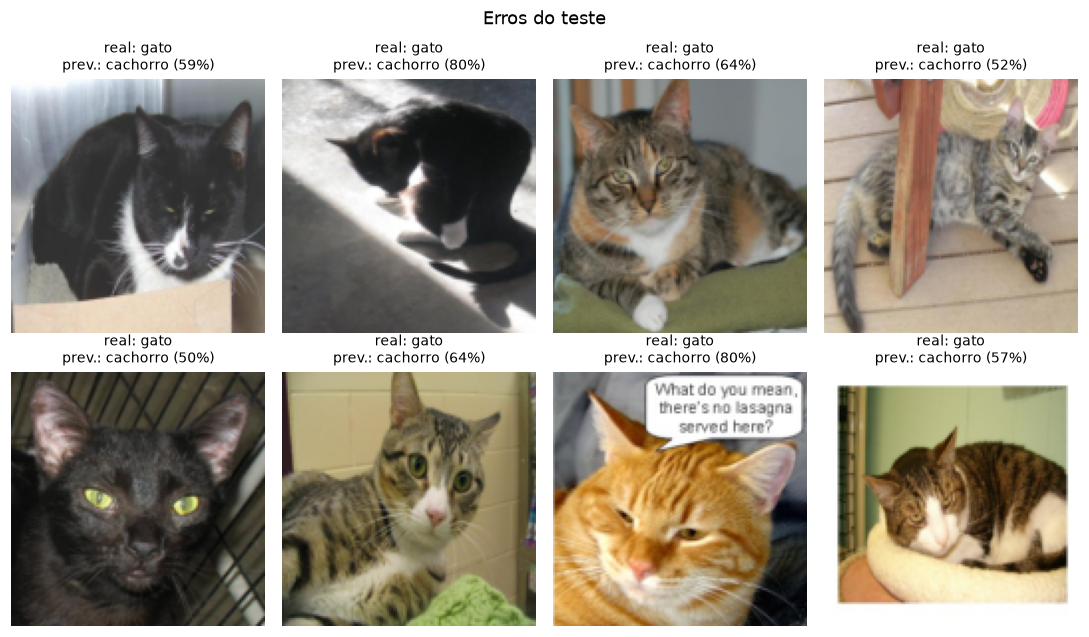

In [12]:
probabilidades = modelo.predict(x_teste, verbose=0).ravel()
previstos = (probabilidades >= 0.5).astype(int)
erros = np.flatnonzero(previstos != y_teste.astype(int))
escolhidos = erros[:8] if len(erros) >= 8 else np.arange(8)

fig, eixos = plt.subplots(2, 4, figsize=(10, 6))
for eixo, indice in zip(eixos.flat, escolhidos):
    eixo.imshow(x_teste[indice])
    real = "cachorro" if y_teste[indice] == 1 else "gato"
    previsto = "cachorro" if previstos[indice] == 1 else "gato"
    confianca = probabilidades[indice] if previstos[indice] == 1 else 1 - probabilidades[indice]
    eixo.set_title(f"real: {real}\nprev.: {previsto} ({confianca:.0%})", fontsize=9)
    eixo.axis("off")
fig.suptitle("Erros do teste" if len(erros) >= 8 else "Amostras do teste")
plt.tight_layout()

## Limites e próximos passos

- O conjunto deriva de uma competição antiga; não representa toda a variedade de animais, câmeras e fundos.
- Uma saída confiante ainda pode estar errada. O modelo não sabe recusar imagens que não contenham cão nem gato.
- O limiar 0,5 é uma convenção deste exemplo, não uma fronteira universal.
- Se treino continuar melhorando enquanto validação piora, há evidência de sobreajuste. Um próximo experimento simples é aplicar espelhamento horizontal **somente ao treino** e comparar as curvas.

O teste final foi mantido fora do treino. Ele oferece uma medida honesta para esta execução, mas não elimina as limitações de amostragem e do orçamento curto.